# **Step2. 상품리뷰분석 Agent2**

## **0. 미션**

### 미션③ : LangSmith 기반 모니터링 시스템 구축
* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석


### 미션④ : Agent 고도화
* [필수] Supervisor 중심 반복 제어
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### 미션⑤ : 대시보드 만들기(streamlit 기반)
* [필수] 기본 대시보드 : 리뷰 결과 집계 및 개별 정보 조회
* [선택항목] 다음은 예시 입니다.
    - 감성분석 결과에 대한 다양한 시각화
    -  Insight Agent 추가 : 요약 리포트 생성 및 개선 제안 도출
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### 워크플로우 V2.0

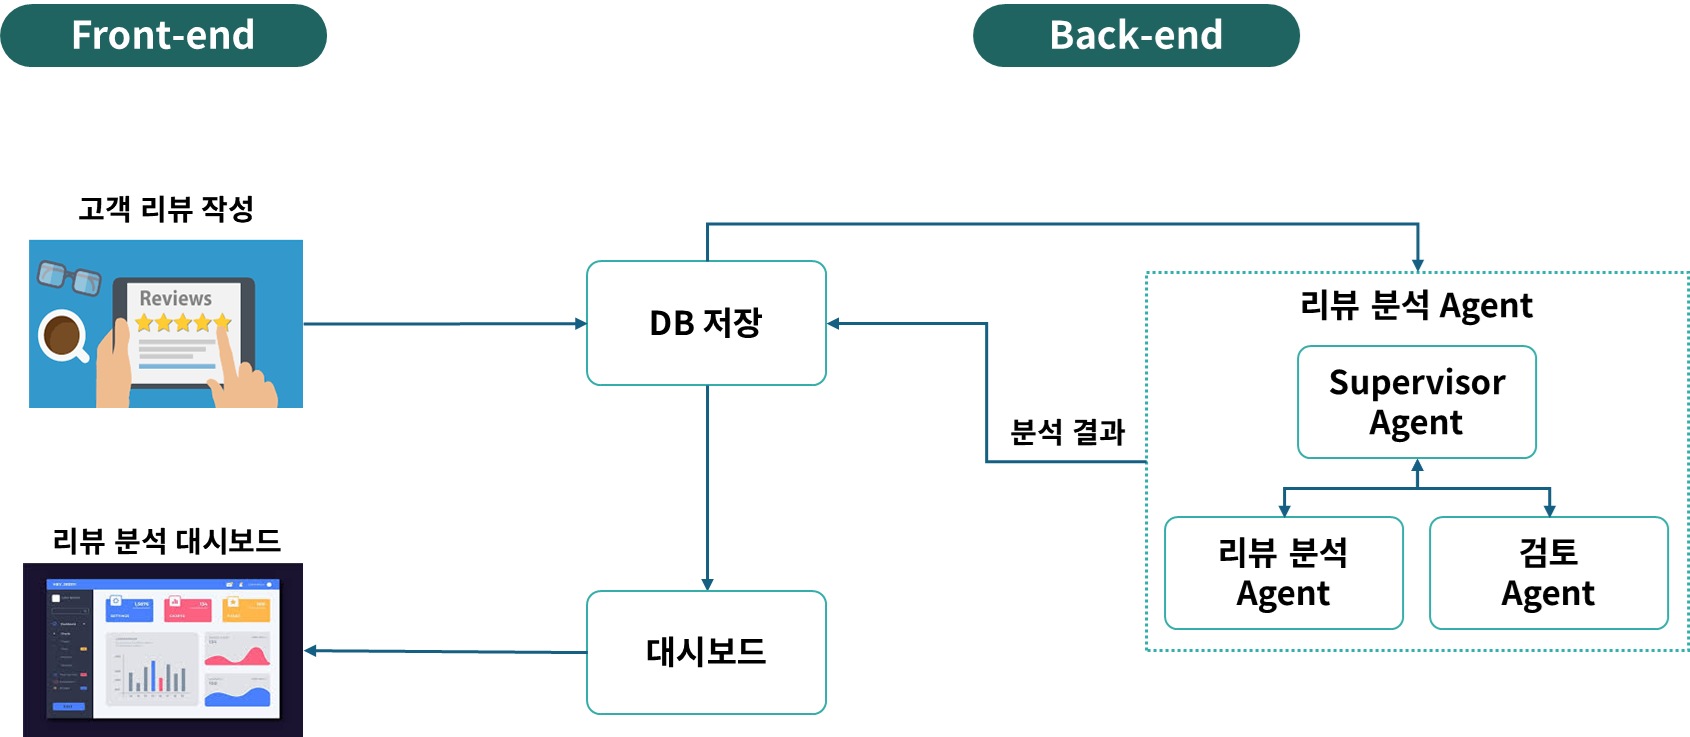

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj2_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!pip install -q langchain-openai langchain-community streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.0/73.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.0 which is incompatible.


* 라이브러리 로딩

In [ ]:
# 기본 제공 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import json
import os
import openai
import ast
import re

from typing import TypedDict, Annotated, List, Optional, Literal, Dict, Any
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import END, START, StateGraph, MessagesState
from langchain_openai import ChatOpenAI

# 더 필요한 라이브러리가 있다면 추가합시다. -----




/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


### (3) OpenAI API Key 확인

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/ai_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

## **2. 미션③ : langsmith 기반 운영 시스템**

* [필수] 실행 Trace : 설정 및 관측 결과 확인
* [선택항목] 다음 항목은 예시 입니다.
	* 평가 : 데이터셋 구성, 평가 지표 설정 및 확인
	* 실패(혹은 오류) 케이스를 만들고 추적 및 원인 분석

### **(1) langsmith 설정**

* langsmith trace에 project 추가 : `proj2_agent`


* 운영환경 설정

In [ ]:
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "llmops_proj"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"

### **(2) Step1 결과물**
* Step1의 결과물을 아래 붙여 넣습니다.

#### **1) State & LLM 준비**

In [ ]:
class ReviewState(TypedDict):
    messages: Annotated[list, add_messages]

    # 입력 리뷰
    review: str

    # 개별 에이전트 실행 결과
    analyzer_result: Optional[str]   # {"items":[{"aspect":..., "label":..., "evidence":...}, ...]}
    critic_result: Optional[str]     # {"verdict":"적합|부적합", "reasons":"..."}

    # 흐름 제어
    retry_count: int
    max_retries: int
    next_agent: Literal["analyzer", "critic", "end"]

* llm 준비

In [ ]:
llm_analyzer = ChatOpenAI(model="gpt-4.1-mini", temperature=0.6)
llm_critic = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0)

#### **2) Agent 노드 준비**
* 필요 Agent : Analyzer Agent, Critic Agent, Supervisor Agent
* 리뷰 결과 State에 담기게 되는 형식 : Dictionary(혹은 JSON)


* Analyzer Agent

In [ ]:
def analyzer_node(state: ReviewState):
    # state 정보 가져오기
    review = state.get("review")
    analyzer_result = state.get("analyzer_result")
    critic_result = state.get("critic_result")

    # 프롬프트 구성
    sys_msg = """
    # 역할
    - 사용자의 리뷰를 분석한다.

    # 지침
    - 사용자의 리뷰에서 속성을 추출하고, 속성기반 감성 분석을 한다.
    - 만약, 이전 분석 결과(analyzer_result)와 이전 분석 평가(critic_result)가 존재한다면, 평가를 반영하여 이전 분석 결과와 다른 분석 결과를 도출한다.

    # 출력 형식
    - 분석 결과는 JSON 형식으로 출력한다.
    - JSON 형태의 분석 결과 이외의 다른 모든 것은 출력하지 않는다.
    - aspect은 분석 대상 속성이며, '보습', '가격', '향', '포장'을 타겟으로 한다.
    - label에는 감성 결과를 0(부정) 또는 1(긍정)로 표현한다.
    - evidence에는 판단의 근거가 된 실제 리뷰 표현이 들어간다.
    ## 출력 예시
    {"items":[{"aspect":..., "label":..., "evidence":...}, ...]}
    """

    hum_msg = f"""
    [사용자 리뷰]
    {review}

    [이전 분석 결과]
    {analyzer_result}

    [이전 분석 평가]
    {critic_result}
    """

    # llm 호출
    response = llm_analyzer.invoke([SystemMessage(content=sys_msg),
                                    HumanMessage(content=hum_msg)])

    return {"messages": [response], "analyzer_result": response.content}

In [ ]:
init_state = {'review':'참 좋은 제품입니다~ 진짜 좋아죽겠네 아주 아오'}
analyzer_node(init_state)['analyzer_result']

'{"items":[{"aspect":"보습","label":1,"evidence":"참 좋은 제품입니다~ 진짜 좋아죽겠네 아주 아오"}]}'

* Critic Agent

In [ ]:
def critic_node(state: ReviewState):
    # state 정보 가져오기
    review = state.get("review")
    analyzer_result = state.get("analyzer_result")

    # 프롬프트 구성
    sys_msg = """
    # 역할
    - 사용자의 리뷰를 분석한 결과를 평가한다.

    # 지침
    - 주어진 분석 결과(analyzer_result)는 사용자 리뷰(review)에서 속성을 추출하고, 속성기반 감성 분석을 한 결과이다.
    - 분석 결과의 데이터 형태는 다음과 같다.
        {"items":[{"aspect":..., "label":..., "evidence":...}, ...]}
    - 사용자 리뷰에서 속성(aspect)을 정확히 추출했는지 평가한다.
    - 사용자 리뷰에서 속성에 따른 감성(label)을 0(부정) 또는 1(긍정)로 정확하게 판단했는지 평가한다.
    - 분석 결과가 사용자 리뷰와 어긋나지 않는지 평가한다.

    # 출력 형식
    - 분석 결과는 JSON 형식으로 출력한다.
    - JSON 형태의 분석 결과 이외의 다른 모든 것은 출력하지 않는다.
    - verdict에는 반드시 적합 또는 부적합 중 하나가 들어가야 한다.
    - reasons에는 종합적인 평가 결과를 객관적이고 상세하게 서술한다.

    ## 출력 예시
    {"verdict":"적합|부적합", "reasons":"..."}
    """

    hum_msg = f"""
    [사용자 리뷰]
    {review}

    [분석 결과]
    {analyzer_result}
    """

    # llm 호출
    response = llm_critic.invoke([SystemMessage(content=sys_msg),
                                    HumanMessage(content=hum_msg)])

    return {"messages": [response], "critic_result": response.content}

* Supervisor Agent

In [ ]:
def supervisor_node(state: ReviewState):
    review = state.get("review")
    analyzer_result = state.get("analyzer_result")
    critic_result = state.get("critic_result")
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 3)

    # next_agent: Literal["analyzer", "critic", "end"]
    if not analyzer_result:
        return {"next_agent": "analyzer"}

    if not critic_result:
        return {"next_agent": "critic"}

    # JSON 파싱
    critique = json.loads(critic_result)
    # {"verdict":"적합|부적합", "reasons":"..."}
    verdict = critique["verdict"]

    if verdict == "적합":
        return {"next_agent": "end"}

    elif verdict == "부적합":
        if retry_count >= max_retries:
            return {"next_agent": "end"}
        else:
            return {
                "next_agent": "analyzer",
                "retry_count": retry_count + 1
            }

    else:
        return {"next_agent": "end"} # 잘못된 경로

#### **3) 그래프 구성**

* route_next 함수

In [ ]:
def route_next(state: ReviewState):
    return state["next_agent"]

* 그래프

In [ ]:
builder = StateGraph(ReviewState)

builder.add_node("supervisor", supervisor_node)
builder.add_node("analyzer", analyzer_node)
builder.add_node("critic", critic_node)

builder.add_edge(START, "supervisor")
builder.add_conditional_edges("supervisor", route_next,
                             {"analyzer": "analyzer",
                              "critic": "critic",
                              "end": END}
                             )
builder.add_edge("analyzer", "supervisor")
builder.add_edge("critic", "supervisor")

app = builder.compile()

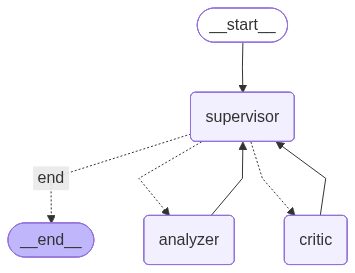

In [ ]:
app

### **(3) 추적 확인**

예제 코드를 통해 추적을 확인해 봅시다.


In [ ]:
# 예시 입력
# review = [
    # "보습력이 정말 좋아요. 향도 은은해서 만족스럽지만 가격은 조금 비싼 편이에요.",
    # "포장이 고급스럽고 배송 상태도 깔끔했어요. 다만 향은 제 취향은 아니었어요.",
    # "가격 대비 보습력이 뛰어나서 재구매 의사 있습니다.",
    # "향이 너무 강해서 오래 사용하기는 힘들 것 같아요.",
    # "포장이 꼼꼼하게 되어 있어서 선물용으로도 좋았습니다.",
    # "보습은 괜찮은데 가격이 생각보다 부담스럽네요.",
    # "향이 은은하고 촉촉하게 발려서 만족합니다.",
    # "포장이 고급스럽고 제품 디자인도 예뻐요.",
    # "보습력은 뛰어나지만 향이 조금 인공적인 느낌이에요.",
    # "가격이 비싸긴 하지만 포장이나 제품 퀄리티는 만족스럽습니다.",
    # "향이 자연스럽고 자극적이지 않아서 좋았어요.",
    # "포장이 부실해서 제품 상자가 찌그러져 왔습니다.",
    # "보습이 오래 유지돼서 건성 피부에 잘 맞아요.",
    # "가격이 조금만 더 저렴했으면 계속 사용할 것 같아요.",
    # "향은 좋았지만 보습력은 기대 이하였습니다.",
    # "포장이 너무 예쁘고 고급스러워서 만족했습니다.",
    # "보습력은 뛰어나지만 가격 때문에 재구매는 고민돼요.",
    # "향이 너무 강해서 사용 후 머리가 아플 정도였어요.",
    # "포장이 깔끔하고 배송도 빨라서 좋았습니다.",
    # "보습, 향, 포장 모두 만족스럽지만 가격이 높은 편이네요."
# ]

In [ ]:
review = """
참 좋은 제품입니다~ 진짜 좋아죽겠네 아주 아오
"""

result = app.invoke({
    "review": review # init_state
})

print("\n===== ANALYZER =====")
print(result["analyzer_result"])
print("\n===== CRITIC =====")
print(result["critic_result"])


===== ANALYZER =====
{"items":[]}

===== CRITIC =====
{"verdict":"부적합", "reasons":"사용자 리뷰는 제품에 대해 매우 긍정적인 감정을 표현하고 있으나, 구체적인 속성인 '보습'에 대한 언급은 전혀 없다. 따라서 '보습'이라는 속성을 추출한 것은 부적절하며, 감성 분석 또한 속성에 기반하지 않은 일반적인 긍정 평가에 불과하다. 분석 결과가 리뷰 내용과 일치하지 않아 부적합하다."}


## **3. 미션④ : Agent 고도화**

* [필수] Supervisor 중심 반복 제어
    - LLM 기반 흐름 제어
    - reason_code 기반 재시도 정책
* [필수] DB에 쌓인 리뷰 예측 batch 처리
* [선택항목] 다음은 예시 입니다.
    - 각 에이전트 고도화 : 성능/정확도를 높이기 위한 프롬프트 개선 등
    - HITL 노드 설계 : 특정 조건 시 Human Review 전환
    - 그 외 팀 내에서 추가 기능 검토 후 구현 가능


### **(1) Supervisor 중심 반복 제어**

* Supervisor Agent : 통제 정책 오케스트레이터(Policy Orchestrator)
    * Critic 판정이 ‘부적합’ 일 때 LLM은
        * critic_reason을 확인하여 reason_code 분류
        * 재시도 시 필요한 짧은 수정 지시를 repair_directive에 저장


#### **1) State 보완**

In [ ]:
ReasonCode = Literal["OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"]

class ReviewState(TypedDict):
  # 입력 리뷰
  review: str

  # 개별 에이전트 실행 결과
  analyzer_result: Optional[str]
  critic_result: Optional[str]
  reason_code: Optional[ReasonCode]
  repair_directive: Optional[str]

  # 흐름 제어
  retry_count: int
  max_retries: int
  next_agent: Literal["analyzer", "critic", "end"]



In [ ]:
llm_analyzer = ChatOpenAI(model="gpt-4.1-mini", temperature=0.6)
llm_critic = ChatOpenAI(model="gpt-4.1-mini", temperature=0.0)

#### **2) Agent 노드 준비**

In [ ]:
# 정책 및 필요 함수 준비 : 아래 내용을 수정해서 사용하세요.

REASON_CODES = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"}
RETRYABLE = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR"}

REPAIR_TEMPLATES = {
    "OUTPUT_ERROR": "dict 1개만 출력. 코드블록/설명 없이 items 구조와 label(0/1)을 맞춰라.",
    "SCOPE_ERROR": "aspect는 기본속성을 우선 고려하되, 추가 속성 중 더 적합한 항목이 있다면 해당 명칭으로 매핑하시오. 다른 표현은 가장 가까운 값으로 매핑하되 연관이 없다면 제외하시오.",
    "EVIDENCE_ERROR": "evidence는 리뷰 원문에 실제로 있는 연속된 문구만 사용하되 **'의미적 포함 관계'**도 포함한다.",
    "QUALITY_ERROR": "리뷰에 없는 내용을 만들지 말고, 애매하면 해당 aspect는 제외하라."
}

# 딕셔너리 파싱 함
def parse_dict(text, default):
    try:
        return ast.literal_eval(text)
    except:
        return default

* Analyzer Agents 보완

In [ ]:
def analyzer_node(state: ReviewState):
    # 1. 입력 데이터 준비
    review = state.get("review", "")
    repair_directive = state.get("repair_directive", "")

    # 2. 프롬프트 구성 (지침 보강)
    system_prompt = """
    # 역할
    - 사용자의 상품 리뷰를 정밀하게 분석하는 화장품 전문 분석가입니다.

    # 지침
    - 리뷰 내용에서 아래 속성들을 추출하고 감성 분석을 수행하세요.
    - 감성 결과(label): 0(부정) 또는 1(긍정)
    - 판단 근거(evidence): 리뷰 본문에서 해당 판단의 근거가 된 핵심 문구를 그대로 인용
    - 모든 리뷰 문장에 대해 먼저 '1단계: 기본 속성'에 해당하는지 확인하세요. 만약 기본 속성에서 적절한 카테고리를 찾을 수 없다면, 그때 '2단계: 확장 속성'을 확인하여 매핑하세요.
    - 주어진 속성에 없는 속성은 생성하지 마시오


    # 1단계: 기본 속성 (Primary Aspects)
    1. 보습 (Moisturizing): 촉촉함, 속당김 해결, 수분감, 건조함 완화.
    2. 가격 (Price/Value): 가성비, 저렴함, 비쌈, 할인, 구성품 혜택.
    3. 향 (Scent): 향기, 냄새, 무향, 잔향, 향의 강도.
    4. 포장 (Packaging): 포장 완충 상태, 박스 파손, 용기 디자인 및 편의성.

    # 2단계: 확장 속성 (Extended Aspects - 1단계에 해당하지 않는 경우 검토)
    5. 제형 (Texture): 발림성, 끈적임, 흡수 속도, 밀착력, 농도.
    6. 자극도 (Irritation): 순함, 따가움, 가려움, 트러블 발생 여부.
    7. 진정 (Soothing): 쿨링감, 피부 진정, 붉은기 완화.
    8. 유수분밸런스 (Oil-Control): 유분기/개기름 조절, 번들거림 방지.
    9. 지속력 (Longevity): 효과 유지 시간, 다크닝 여부, 메이크업 고정력.
    10. 피부톤 (Tone): 미백, 안색 개선, 화사함, 잡티 완화.
    11. 탄력 (Elasticity): 리프팅, 주름 개선, 탱탱함, 영양감.
    12. 세정력 (Cleansing): 노폐물 제거 정도, 세안 후 잔여감.
    13. 성분 (Ingredients): 특정 성분 언급(시카, 레티놀 등), 성분 안전성.
    14. 색상 (Color): 발색력, 컬러 만족도, 호수(21호 등) 적합성.
    15. 배송 (Delivery): 배송 속도(빠름/느림)

    # 분석 원칙
    -
    - 애매한 것을 억지로 끼워 맞추는 것은 'SCOPE_ERROR'로 간주됩니다.

    # 품질 원칙 (중요)
    1. 언급되지 않은 속성은 절대로 출력하지 마세요.
    2. 확실한 정보만 추출하는 것이 억지로 분석하는 것보다 중요합니다.

    # 출력 형식
    - 반드시 아래 JSON 형식으로만 답변하세요.
    {
      "items": [
        {"aspect": "속성명", "label": 0, "evidence": "근거 문구"},
        ...
      ]
    }
    """

    # 유저 컨텐츠 구성
    if repair_directive:
        user_content = f"""
        [필독: 수정 지시사항 반영 요청]
        이전 분석에서 오류가 있었습니다. 이전의 오답을 완전히 잊고, 아래 지시사항을 반영하여 다시 분석하세요:
        >>> {repair_directive} <<<

        [리뷰 원문]
        {review}
        """
    else:
        user_content = f"""
        [리뷰 원문]
        {review}
        위 리뷰에 대해 속성 기반 감성 분석을 수행하세요.
        """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    try:
        response = llm_analyzer.invoke(messages)
        content = response.content.strip()

        # [방어 로직] 응답이 이미 dict라면 파싱 생략, str이라면 파싱 수행
        if isinstance(content, dict):
            analyzer_result = content
        else:
            # 마크다운 제거
            if "```json" in content:
                content = content.split("```json")[1].split("```")[0].strip()
            elif "```" in content:
                content = content.split("```")[1].split("```")[0].strip()

            analyzer_result = json.loads(content)

    except Exception as e:
        print(f"Analyzer Error: {e}")
        # 오류 발생 시 빈 결과물 반환 (이후 Critic이 QUALITY_ERROR로 처리하도록 유도)
        analyzer_result = {"items": []}

    return {
        "analyzer_result": analyzer_result
    }

* Critic Agent 보완

In [ ]:
def critic_node(state: ReviewState):
    # State에서 데이터 추출
    review = state.get("review", "")
    analyzer_result = state.get("analyzer_result", {})

    # 프롬프트 구성
    system_prompt = """
    당신은 화장품 리뷰 분석의 품질을 보증하는 'critic' 에이전트입니다.
    'analyzer'가 분석한 결과가 원문과 일치하거나 유사한지 검토하시오

    [검토 및 분류 기준]
    - OUTPUT_ERROR: 출력 형식/스키마 오류, JSON 파싱 실패, label 범위 오류 등
    - SCOPE_ERROR: 허용 범위 밖의 속성(aspect) 사용, 동의어 처리 실패 등
    - EVIDENCE_ERROR: 근거 문구가 원문과 불일치, 요약 형태, 근거 없음 등
    - QUALITY_ERROR: 환각(Hallucination), 감성 판단 모호, 분석 품질 저하 등


    [출력 규칙 - 중요]
    - 반드시 아래 JSON 형식으로만 응답하세요.
    - 마크다운 코드를 절대 사용하지 마세요. 오직 순수 JSON 텍스트만 출력하세요.
    - 일치하면 verdict를 "적합", reason_code를 "OK"로 설정하세요. (사용자 변수 REASON_CODES에 맞춤)
    - 불일치하면 verdict를 "부적합"으로 하고, 위 기준에 따라 reason_code를 선택하세요.
    - analyzer_result가 비어있으면 QUALITY_ERROR로 처리하라


    {
      "critic_result": {
        "verdict": "적합" 또는 "부적합",
        "reason_code": "OUTPUT_ERROR" | "SCOPE_ERROR" | "EVIDENCE_ERROR" | "QUALITY_ERROR" | "OK",
        "reason": "검토 의견 상세 내용"
      }
    }
    """

    user_content = f"""
    [리뷰 원문]
    {review}

    [Analyzer의 분석 결과]
    {json.dumps(analyzer_result, ensure_ascii=False)}

    위 결과가 적절한지 검토하여 결과를 보고하세요.
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    try:
        response = llm_critic.invoke(messages)


        res_content = response.content

        if isinstance(res_content, dict):
            # 이미 딕셔너리라면 바로 사용
            parsed_data = res_content
        else:
            # 문자열이라면 마크다운 제거 후 JSON 파싱
            clean_content = str(res_content).replace("```json", "").replace("```", "").strip()
            parsed_data = json.loads(clean_content)

        critic_result = parsed_data.get("critic_result", {
            "verdict": "부적합",
            "reason": "응답 형식이 올바르지 않습니다."
        })

        reason_code = critic_result.get("reason_code")
        if not reason_code:
            reason_code = "OK" if critic_result.get("verdict") == "적합" else "QUALITY_ERROR"

    except Exception as e:
        print(f"[Error] critic_node parsing error: {e}")
        critic_result = {
            "verdict": "부적합",
            "reason": f"검토 중 기술적 오류 발생: {str(e)}"
        }
        reason_code = "OUTPUT_ERROR"

    return {
        "critic_result": critic_result,
        "reason_code": reason_code
    }

* Supervisor Agent 보완

In [ ]:
def supervisor_node(state: ReviewState):
    # 1. State 데이터 추출
    review = state.get("review", "")
    analyzer_result = state.get("analyzer_result")
    critic_result = state.get("critic_result")
    reason_code = state.get("reason_code")
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 3)

    # [분석 전] 결과가 없으면 분석기로 보냄
    if analyzer_result is None:
        return {"next_agent": "analyzer"}

    # [검증 전] 분석은 있으나 검증 결과가 없으면 크리틱으로 보냄
    if not critic_result:
        return {"next_agent": "critic"}

    # 2. 판정 결과(verdict) 확인
    verdict = critic_result.get("verdict")

    # [Case 1] 적합한 경우 -> 종료
    if verdict == "적합" or reason_code == "OK":
        return {"next_agent": "end"}

    # [Case 2] 부적합한 경우 -> 재시도 판단
    if verdict == "부적합":
        # 재시도 가능 여부와 횟수 확인
        is_retryable = reason_code in RETRYABLE

        if is_retryable and retry_count < max_retries:
            # 에러 코드에 맞는 수정 지시문(Template) 추출
            directive = REPAIR_TEMPLATES.get(reason_code, "이전 분석의 오류를 수정하세요.")

            # 다음 노드(Analyzer)를 위해 상태 업데이트
            return {
                "next_agent": "analyzer",
                "retry_count": retry_count + 1,
                "repair_directive": directive,  # 짧은 수정 지침 저장
                "critic_result": None, # 초기화하여 다음 루프 준비
                "reason_code": None
            }
        else:
            # 재시도 불가능한 에러(QUALITY_ERROR)이거나 횟수 초과 시 종료
            return {"next_agent": "end"}

    return {"next_agent": "end"}

* route_next 함수

In [ ]:
def route_next(state: ReviewState) -> str:
    return state["next_agent"]

* 그래프

In [ ]:
builder = StateGraph(ReviewState)

# 1. 노드 추가
builder.add_node("supervisor", supervisor_node)
builder.add_node("analyzer", analyzer_node)
builder.add_node("critic", critic_node)


# 2. 시작 엣지
builder.add_edge(START, "supervisor")

# 3. 조건부 엣지 (supervisor가 모든 흐름을 제어)
builder.add_conditional_edges(
    "supervisor",
    route_next,
    {
        "analyzer": "analyzer",
        "critic": "critic",
        "end": END
    }
)

# 4. 일반 엣지 연결 (모든 노드는 다시 supervisor로 돌아감)
builder.add_edge("analyzer", "supervisor")
builder.add_edge("critic", "supervisor")

app = builder.compile()

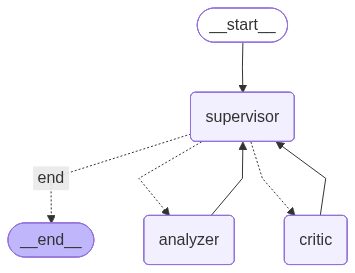

In [ ]:
app

* 실행 테스트

In [ ]:
import json

# 1. 분석할 리뷰 정의
review = "12 "
# 2. 초기 상태(init_state) 설정
init_state: ReviewState = {
    "review": review,
    "analyzer_result": None,
    "critic_result": None,
    "reason_code": None,
    "repair_directive": None,
    "retry_count": 0,
    "max_retries": 3,
    "next_agent": "analyzer",
}

# 3. 그래프 실행
# invoke 과정에서 발생할 수 있는 전체적인 예외를 잡아주면 배치가 멈추지 않습니다.
try:
    result = app.invoke(init_state)
except Exception as e:
    print(f"!!! 그래프 실행 중 치명적 오류 발생: {e}")
    result = init_state # 에러 시 초기 상태라도 유지

# 4. 결과 출력 및 확인 (가독성 보완)
print("\n" + "="*50)
print("             [최종 분석 리포트]")
print("="*50)

# 분석 결과 출력
analyzer_res = result.get("analyzer_result", {})
if isinstance(analyzer_res, str): # 혹시 문자열로 들어올 경우 대비
    try: analyzer_res = json.loads(analyzer_res)
    except: pass

print(f"▶ 리뷰 원문: {result.get('review').strip()}")
print(f"▶ 추출 결과: {json.dumps(analyzer_res, indent=2, ensure_ascii=False)}")

print("-"*50)

# 크리틱 판정 상세
critic_res = result.get('critic_result', {})
verdict = critic_res.get('verdict', 'N/A')
reason_code = result.get('reason_code', 'N/A')
# 사유는 critic_result 안의 reason 혹은 repair_directive 둘 다 확인
reason_detail = critic_res.get('reason') or result.get('repair_directive') or "사유 없음"

print(f"▶ 크리틱 판정: {verdict}")
print(f"▶ 사유 코드  : {reason_code}")
print(f"▶ 상세 사유  : {reason_detail}")

print("-"*50)

# 실행 통계
retry_cnt = result.get('retry_count', 0)
max_retry = result.get('max_retries', 3)
print(f"▶ 최종 재시도: {retry_cnt} / {max_retry}")
print("="*50)

# 최종 DB 저장용 데이터 추출 (테스트용)
final_items = analyzer_res.get("items", [])
print(f"최종 추출 개수: {len(final_items)}개")


             [최종 분석 리포트]
▶ 리뷰 원문: 12
▶ 추출 결과: {
  "items": []
}
--------------------------------------------------
▶ 크리틱 판정: 부적합
▶ 사유 코드  : QUALITY_ERROR
▶ 상세 사유  : 리뷰 원문이 매우 짧고 의미 있는 내용이 없으나, analyzer_result가 비어 있어 분석 품질이 저하됨.
--------------------------------------------------
▶ 최종 재시도: 0 / 3
최종 추출 개수: 0개


In [ ]:
import json

# 분석할 리뷰 리스트
review_list = [
    "보습력이 정말 좋아요. 향도 은은해서 만족스럽지만 가격은 조금 비싼 편이에요.",
    "포장이 고급스럽고 배송 상태도 깔끔했어요. 다만 향은 제 취향은 아니었어요.",
    "가격 대비 보습력이 뛰어나서 재구매 의사 있습니다.",
    "향이 너무 강해서 오래 사용하기는 힘들 것 같아요.",
    "포장이 꼼꼼하게 되어 있어서 선물용으로도 좋았습니다.",
    "보습은 괜찮은데 가격이 생각보다 부담스럽네요.",
    "향이 은은하고 촉촉하게 발려서 만족합니다.",
    "포장이 고급스럽고 제품 디자인도 예뻐요.",
    "보습력은 뛰어나지만 향이 조금 인공적인 느낌이에요.",
    "가격이 비싸긴 하지만 포장이나 제품 퀄리티는 만족스럽습니다.",
    "향이 자연스럽고 자극적이지 않아서 좋았어요.",
    "포장이 부실해서 제품 상자가 찌그러져 왔습니다.",
    "보습이 오래 유지돼서 건성 피부에 잘 맞아요.",
    "가격이 조금만 더 저렴했으면 계속 사용할 것 같아요.",
    "향은 좋았지만 보습력은 기대 이하였습니다.",
    "포장이 너무 예쁘고 고급스러워서 만족했습니다.",
    "보습력은 뛰어나지만 가격 때문에 재구매는 고민돼요.",
    "향이 너무 강해서 사용 후 머리가 아플 정도였어요.",
    "포장이 깔끔하고 배송도 빨라서 좋았습니다.",
    "보습, 향, 포장 모두 만족스럽지만 가격이 높은 편이네요."
]

print(f"📦 총 {len(review_list)}개의 리뷰 분석을 시작합니다.")

for i, review_text in enumerate(review_list):
    print("\n" + "■"*60)
    print(f"🔍 [{i+1}/{len(review_list)}] 리뷰 분석 프로세스 가동")
    print(f"📝 원문: {review_text}")
    print("■"*60)

    init_state = {
        "review": review_text,
        "analyzer_result": None,
        "critic_result": None,
        "reason_code": None,
        "repair_directive": None,
        "retry_count": 0,
        "max_retries": 3,
        "next_agent": "analyzer",
    }

    # 에이전트 협업 과정 스트리밍
    for output in app.stream(init_state):
        for node_name, node_state in output.items():
            print(f"\n[Node: {node_name}]")

            # 1. Analyzer 결과 출력
            if "analyzer_result" in node_state and node_state["analyzer_result"]:
                print(f" - 분석결과: {json.dumps(node_state['analyzer_result'], ensure_ascii=False)}")

            # 2. Critic 결과 및 [사유 코드] 출력
            if "critic_result" in node_state and node_state["critic_result"]:
                crit = node_state["critic_result"]
                # critic 노드가 내뱉는 reason_code 출력
                r_code = node_state.get("reason_code", "N/A")
                print(f" - 검증결과: {{'verdict': '{crit.get('verdict')}', 'reason': '{crit.get('reason')}'}}")
                if crit.get('verdict') == "부적합":
                    print(f" - ⚠️ 사유 코드: {r_code}")

            # 3. Supervisor 피드백 및 [재분석 지시] 출력
            if "repair_directive" in node_state and node_state["repair_directive"]:
                retry_idx = node_state.get('retry_count', 0)
                # supervisor 단계에서도 현재 어떤 에러를 고치라고 하는지 명시
                print(f" - 🔄 재분석 지시 ({retry_idx}회차)")
                print(f" - 피드백: [\"{node_state['repair_directive']}\"]")

        print("-" * 40)

    print(f"\n✅ 리뷰 [{i+1}] 최종 분석 완료")

print("\n" + "="*60)
print("🏁 모든 리뷰에 대한 배치 분석이 완료되었습니다!")
print("="*60)

📦 총 20개의 리뷰 분석을 시작합니다.

■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
🔍 [1/20] 리뷰 분석 프로세스 가동
📝 원문: 보습력이 정말 좋아요. 향도 은은해서 만족스럽지만 가격은 조금 비싼 편이에요.
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

[Node: supervisor]
----------------------------------------

[Node: analyzer]
 - 분석결과: {"items": [{"aspect": "보습", "label": 1, "evidence": "보습력이 정말 좋아요."}, {"aspect": "향", "label": 1, "evidence": "향도 은은해서 만족스럽지만"}, {"aspect": "가격", "label": 0, "evidence": "가격은 조금 비싼 편이에요."}]}
----------------------------------------

[Node: supervisor]
----------------------------------------

[Node: critic]
 - 검증결과: {'verdict': '적합', 'reason': '분석 결과가 원문과 일치하며, 각 속성에 대한 감성 판단과 근거 문구가 적절하게 매칭되어 있음.'}
----------------------------------------

[Node: supervisor]
----------------------------------------

✅ 리뷰 [1] 최종 분석 완료

■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
🔍 [2/20] 리뷰 분석 프로세스 가동
📝 원문: 포장이 고급스럽고 배송 상태도 깔끔했어요. 다만 향은 제 취향은 아니었어요.
■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■

### **(2) DB에 쌓인 리뷰 예측 batch 처리**

* 리뷰 데이터 여러 건을 임의로 생성하여 Step1에서 생성한 DB의 테이블에 저장.
* DB에서 분석 대상 리뷰 조회(예: agent_aspect가 NULL인 데이터)
* 각 리뷰에 대해 Agent 실행
* 분석 결과(items)에서 aspect , label 추출
* DB에 결과 저장 (UPDATE)


#### **1) 데이터 준비**
* data.csv 파일 로딩
* review 칼럼의 값만 DB에 저장

In [ ]:
# 코랩에 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving data.csv to data.csv


In [ ]:
# @title
review_test_data = [
    # 쉬운 리뷰 10개
    {
        "review": "보습감이 좋아서 피부가 오래 촉촉했어요.",
    },
    {
        "review": "가격이 저렴해서 부담 없이 구매했습니다.",
        "agent_aspect": "가격",
        "agent_label": 1
    },
    {
        "review": "향이 너무 강해서 사용하기 불편했어요.",
        "agent_aspect": "향",
        "agent_label": 0
    },
    {
        "review": "포장이 깔끔해서 선물용으로 좋았습니다.",
        "agent_aspect": "포장",
        "agent_label": 1
    },
    {
        "review": "보습은 좋은데 가격이 조금 비싸요.",
        "agent_aspect": "보습",
        "agent_label": 1
    },
    {
        "review": "보습은 좋은데 가격이 조금 비싸요.",
    },
    {
        "review": "향이 은은하고 기분 좋아지는 느낌이에요.",
        "agent_aspect": "향",
        "agent_label": 1
    },
    {
        "review": "포장이 찌그러져 와서 아쉬웠습니다.",
    },
    {
        "review": "가격 대비 품질이 좋아서 만족합니다.",
        "agent_aspect": "가격",
        "agent_label": 1
    },
    {
        "review": "가격 대비 품질이 좋아서 만족합니다.",
    },
    {
        "review": "보습력이 부족해서 금방 건조해졌어요.",
        "agent_aspect": "보습",
        "agent_label": 0
    },
    {
        "review": "향도 좋고 포장도 예뻐서 마음에 들었습니다.",
        "agent_aspect": "향",
        "agent_label": 1
    },
    {
        "review": "향도 좋고 포장도 예뻐서 마음에 들었습니다.",
        "agent_aspect": "포장",
        "agent_label": 1
    }
]

In [ ]:
df = pd.DataFrame(review_test_data)
df

,review,agent_aspect,agent_label
0,보습감이 좋아서 피부가 오래 촉촉했어요.,NaN,NaN
1,가격이 저렴해서 부담 없이 구매했습니다.,가격,1.0
2,향이 너무 강해서 사용하기 불편했어요.,향,0.0
3,포장이 깔끔해서 선물용으로 좋았습니다.,포장,1.0
4,보습은 좋은데 가격이 조금 비싸요.,보습,1.0
5,보습은 좋은데 가격이 조금 비싸요.,NaN,NaN
6,향이 은은하고 기분 좋아지는 느낌이에요.,향,1.0
7,포장이 찌그러져 와서 아쉬웠습니다.,NaN,NaN
8,가격 대비 품질이 좋아서 만족합니다.,가격,1.0
9,가격 대비 품질이 좋아서 만족합니다.,NaN,NaN


In [ ]:
# CSV를 DataFrame으로 로드
df = pd.read_csv("data.csv")

# 데이터 확인
df.head()

,review,aspect,label
0,연령상관없이 요즘 너무 인기 있어서 한번 사봤습니다. 도대체 얼마나 좋길래 다들 O...,['가격'],[0]
1,구매후 3일정도 사용하고 후기 작성하는데요. 최근 들어 탈모가 심해지는것 같아서 탈...,['향'],[1]
2,친구랑 같이 기숙사에 사는데 어느 날 친구가 이 향수를 사 왔더라구요?? 향이 어떨...,['향'],[1]
3,써보고 주위 선물 하려고 샀어요. 눈 주위에 바르고 있는데 덜 건조하고 촉촉해요 휴...,['보습'],[1]
4,택배 잘 받았어요. 처음으로 주문해서 써봤는데 발림성이 부드러워서 좋고 용량이 많아...,"['가격', '포장']","[1, 1]"


In [ ]:
df.head()

,review,aspect,label
0,연령상관없이 요즘 너무 인기 있어서 한번 사봤습니다. 도대체 얼마나 좋길래 다들 O...,['가격'],[0]
1,구매후 3일정도 사용하고 후기 작성하는데요. 최근 들어 탈모가 심해지는것 같아서 탈...,['향'],[1]
2,친구랑 같이 기숙사에 사는데 어느 날 친구가 이 향수를 사 왔더라구요?? 향이 어떨...,['향'],[1]
3,써보고 주위 선물 하려고 샀어요. 눈 주위에 바르고 있는데 덜 건조하고 촉촉해요 휴...,['보습'],[1]
4,택배 잘 받았어요. 처음으로 주문해서 써봤는데 발림성이 부드러워서 좋고 용량이 많아...,"['가격', '포장']","[1, 1]"


In [ ]:
# review 컬럼만 추출
reviews = df["review"].tolist()

In [ ]:
from datetime import datetime, timezone, timedelta

KST = timezone(timedelta(hours=9))

def now_kst():
    return datetime.now(KST).strftime("%Y-%m-%d %H:%M:%S")

# DB 연결
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# 테이블 생성
# IF NOT EXISTS: 중복 테이블 생성 방지
# UNIQUE: 중복 데이터 방지
cursor.execute("""
CREATE TABLE IF NOT EXISTS review_analysis (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    review TEXT NOT NULL UNIQUE,
    agent_aspect JSON NOT NULL,
    agent_label JSON NOT NULL,
    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")

# commit
conn.commit()
conn.close()

In [ ]:
# DB 연결
conn = sqlite3.connect("reviews.db")
cursor = conn.cursor()

# review 데이터 삽입
insert_data = []

for review in reviews:

    insert_data.append(
        (
            review,
            json.dumps([], ensure_ascii=False),  # 빈 aspect
            json.dumps([])                       # 빈 label
        )
    )

# batch insert
cursor.executemany(
    """
    INSERT OR IGNORE INTO review_analysis
    (review, agent_aspect, agent_label)
    VALUES (?, ?, ?)
    """,
    insert_data
)

# commit
conn.commit()
conn.close()

In [ ]:
conn.close()

In [ ]:
# 데이터 조회 확인
conn = sqlite3.connect("reviews.db")
cursor = conn.cursor()

cursor.execute("SELECT * FROM review_analysis LIMIT 5")   # 상위 5개 데이터 조회
# cursor.execute("SELECT * FROM review_analysis")           # 전체 데이터 조회
rows = cursor.fetchall()

for row in rows:
    print(row)

# 전체 데이터 개수 조회
cursor.execute("SELECT COUNT(*) FROM review_analysis")

total_count = cursor.fetchone()[0]

print(f"\n전체 데이터 수 : {total_count}")

conn.close()

(1, '연령상관없이 요즘 너무 인기 있어서 한번 사봤습니다. 도대체 얼마나 좋길래 다들 OO OO 하는지 써보겠습니다. 다만 가격이 비싸서 아쉽고 구성도 더 알찼으면 좋았을 거 같아요.', '[]', '[]', '2026-05-13 03:46:11')
(2, '구매후 3일정도 사용하고 후기 작성하는데요. 최근 들어 탈모가 심해지는것 같아서 탈모샴푸를 알아보게 됐어요. 그동안 그냥 일반샴푸만 사용하다가 탈모샴푸를 처음 써봐서 다른 제품과의 비교는 할 수 없지만 나름대로 느낌점을 써보는데요. 제형이 밀도가 높다는 느낌이 들었어요. 그리고 은은한 민트향이 너무 좋았네요. 앞으로 꾸준히 사용해봐야 효과를 볼 수 있겠지만 짧게나마 느낀점 작성해봅니다.', '[]', '[]', '2026-05-13 03:46:11')
(3, '친구랑 같이 기숙사에 사는데 어느 날 친구가 이 향수를 사 왔더라구요?? 향이 어떨지 하고 저도 뿌려봤는데 향이 너무 좋아서 사게 되었어요!! 후기 알려 드릴게요~ 일단 저는 향수를 자주 사용하는 편이라 집에 향수가 많지만 그래도 구매를 하게 되었습니다! 향이 안 좋은 것도 많이 사서 실패도 많이 해서 그런지 이번에는 잘 구매한 것 같습니다!! 일단 이 제품은 향이 강하지 않아서 좋았어요~ 약간 은은하게 남성다운 향이 나서 좋았던 것 같습니다~ 지속력은 생각보다 길지 않아서 자주 뿌리게 되긴 하네요! 그래도 뿌릴 때 마다 기분이 좋아요! 향이 좋거든요 ㅋㅋㅋㅋ 그리고 직접 사시면 아시겠지만 이거 디자인이 아주 물건입니다!! 디자인이 완전 고급스러워 보여요 한 달 정도 사용했는데 너무 좋네요!! 당분간은 이 향수만 쭉 쓸 것 같아요!! 추천 합니다^^', '[]', '[]', '2026-05-13 03:46:11')
(4, '써보고 주위 선물 하려고 샀어요. 눈 주위에 바르고 있는데 덜 건조하고 촉촉해요 휴대하기도 편해서 좋아요', '[]', '[]', '2026-05-13 03:46:11')
(5, '택배 잘 받았어요. 처음으로 주문해서 써봤는데

#### **2) 리뷰를 읽어서 Agent 실행후 결과 저장**

In [ ]:
# 1) 미처리 리뷰 조회 함수
# 미처리 리뷰: 속성기반 감성 분석이 이루어지지 않은 review
#             agent_aspect, agent_label가 빈 리스트인 경우
def get_unprocessed_reviews():

    # DB 연결
    conn = sqlite3.connect("reviews.db")
    cursor = conn.cursor()

    # agent_aspect, agent_label가 빈 리스트([])인 데이터 조회
    cursor.execute("""
        SELECT id, review
        FROM review_analysis
        WHERE agent_aspect = '[]' AND agent_label = '[]'
    """)

    rows = cursor.fetchall()

    conn.close()

    return rows

In [ ]:
def extract_result(result):
    """
    에이전트 결과에서 aspect와 label 리스트를 안전하게 추출합니다.
    """
    # 1. analyzer_result 가져오기
    analyzer_result = result.get("analyzer_result")

    # 데이터가 아예 없는 경우 빈 리스트 반환
    if not analyzer_result:
        return [], []

    # 2. [핵심] 타입별 처리 로직
    if isinstance(analyzer_result, dict):
        # 이미 딕셔너리라면 바로 사용 (에러 발생 원천 봉쇄)
        final_dict = analyzer_result
    elif isinstance(analyzer_result, str):
        # 문자열(JSON)인 경우에만 loads 실행
        try:
            final_dict = json.loads(analyzer_result)
        except Exception:
            return [], []
    else:
        return [], []

    # 3. items 안전하게 추출
    items = final_dict.get("items", [])

    aspect_list = [item["aspect"] for item in items]
    label_list = [item["label"] for item in items]

    return aspect_list, label_list

In [ ]:
# 3) DB 업데이트
def update_result(review_id, aspect_list, label_list):

    # DB 연결
    conn = sqlite3.connect("reviews.db")
    cursor = conn.cursor()

    # UPDATE
    cursor.execute(
        """
        UPDATE review_analysis
        SET
            agent_aspect = ?,
            agent_label = ?,
            updated_at = CURRENT_TIMESTAMP
        WHERE id = ?
        """,
        (
            json.dumps(aspect_list, ensure_ascii=False),
            json.dumps(label_list),
            review_id
        )
    )

    # commit
    conn.commit()
    conn.close()

In [ ]:
# 4) batch 실행
def run_batch_analysis(state=None):
    # 미처리 리뷰 조회
    rows = get_unprocessed_reviews()
    print(f"미처리 리뷰 개수 : {len(rows)}")

    # [수정] state 없으면 기본 state 생성
    if state is None:
        # Graph 초기 State 구성 (필요한 모든 키 포함)
        init_state = {
            "review": None,
            "analyzer_result": None,
            "critic_result": None,
            "reason_code": None,
            "repair_directive": None,
            "retry_count": 0,
            "max_retries": 3,
            "next_agent": "analyzer",
            "aspect_list": [],
            "aspect_count_result": None
        }
    # [수정] state 있으면 aspect_list, aspect_count_result 값 전달
    else:
        init_state = state

    # batch loop
    for row in rows:
        review_id = row[0]
        review_content = row[1]

        print("\n" + "="*40)
        print(f"🔍 리뷰 ID : {review_id} 분석 시작")
        print(f"💬 내용 : {review_content[:50]}...") # 너무 길면 잘라서 출력

        # review state 업데이트
        init_state["review"] = review_content

        try:
            # Agent 실행
            result = app.invoke(init_state)

            # aspect, label 추출 (안전하게 수정된 함수 호출)
            aspect_list, label_list = extract_result(result)

            print(f"✅ 결과 - 속성: {aspect_list}")
            print(f"✅ 결과 - 라벨: {label_list}")


            # DB 업데이트
            update_result(review_id, aspect_list, label_list)

        except Exception as e:
            # 배치 작업 중 하나가 에러 나도 멈추지 않도록 예외 처리
            print(f"❌ 리뷰 {review_id} 처리 중 오류 발생: {e}")
            continue

    print("\n" + "="*40)
    print("🏁 Batch 작업 전면 완료")

In [ ]:
# 배치 실행
run_batch_analysis()


# 실행 결과 확인
conn = sqlite3.connect("reviews.db")
cursor = conn.cursor()

cursor.execute("""
SELECT *
FROM review_analysis
LIMIT 10
""")

rows = cursor.fetchall()

print("\n========= 최종 DB 결과 =========\n")

for row in rows:
    print(row)

conn.close()


미처리 리뷰 개수 : 105

🔍 리뷰 ID : 96 분석 시작
💬 내용 : 항상 쓰던 제품입니다. 봄과 여름에 사용하기 좋고 여성스러운 향이라 만족해요. 향이 강하지...
✅ 결과 - 속성: ['향']
✅ 결과 - 라벨: [1]

🔍 리뷰 ID : 97 분석 시작
💬 내용 : 향수 같은 인조 향이라기보다는 자연의 향을 담고 있어서 좋아요. 본디 탈모샴푸 이기 때문에...
✅ 결과 - 속성: ['향']
✅ 결과 - 라벨: [1]

🔍 리뷰 ID : 98 분석 시작
💬 내용 : 친구가 추천을 해줘서 사용하게 된 팩인데 제가 데일리로 매일 사용하고 있어서 추천 드리고 ...
✅ 결과 - 속성: ['보습', '제형']
✅ 결과 - 라벨: [1, 1]

🔍 리뷰 ID : 99 분석 시작
💬 내용 : 매번 쓰던 제품입니다. 신랑이 두피가 민감해서 꼭 이 제품만 쓰려고 고집을 하네요. 가격도...
✅ 결과 - 속성: ['가격', '포장', '자극도']
✅ 결과 - 라벨: [1, 1, 1]

🔍 리뷰 ID : 100 분석 시작
💬 내용 : 파우치에서 꺼내는 순간 주변의 모든 여자가 알아볼 수 있을 만큼 유명한 제품이죠. OO O...
✅ 결과 - 속성: ['보습', '색상', '포장']
✅ 결과 - 라벨: [1, 1, 1]

🔍 리뷰 ID : 101 분석 시작
💬 내용 : 늘 쓰던 제품이 품절이라 새로운 제품을 시도해보고 싶어서 구입했어요. 근데 양도 너무 작고...
✅ 결과 - 속성: ['가격', '지속력', '포장', '지속력']
✅ 결과 - 라벨: [0, 0, 1, 1]

🔍 리뷰 ID : 102 분석 시작
💬 내용 : 자연스럽게 새치 커버가 되서 머리 감을때마다 기분전환이 됩니다. 향도 좋고 세정력도 좋아서...
✅ 결과 - 속성: ['향', '세정력']
✅ 결과 - 라벨: [1, 1]

🔍 리뷰 ID : 103 분석 시작
💬 내용 : 타사제품21호써서21호로주문했는데 너무밝은거같아23호로 교환신청합니다. 잘먹는편이고 퍼프가...
✅ 결과 - 속성: ['색상', '

## **4. 미션⑤ : 대시보드 만들기**

### (1) 한글 폰트 준비

* 한글폰트 설치

In [ ]:
!apt-get -y install fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 0s (41.2 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118251 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


* 세션 다시시작

### **(2) 대시보드 앱 : app.py**

* 최소 요구사항
    * 프레임1 : 상품리뷰 결과를 분석하는 그래프
    * 프레임2 : 리뷰 분석 결과 건별 조회


In [ ]:
%%writefile app.py
import ast
import json
import sqlite3
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns
from typing import TypedDict, Optional, Dict, Any, Literal, Annotated

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

from matplotlib.ticker import MaxNLocator

# 한글 폰트 세팅 -------------------------------
def set_korean_font():
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()

    mpl.rcParams["font.family"] = font_name
    mpl.rcParams["axes.unicode_minus"] = False

    sns.set_theme(style="whitegrid", rc={
        "font.family": font_name,
        "axes.unicode_minus": False
    })

    return fm.FontProperties(fname=font_path)

font_prop = set_korean_font()


# -----------------------------
# 1. 함수, 데이터 준비
# -----------------------------

db_path = '/content/drive/MyDrive/미니프로젝트_3차/reviews.db'
st.set_page_config(page_title="상품 리뷰 분석 Agent", layout="wide")

# [수정] JSON 변환 및 타입 방어 함수
def safe_parse_json(data):
    """문자열이면 파싱하고, 이미 dict/list라면 그대로 반환하여 TypeError 방지"""
    if data is None:
        return {}
    if isinstance(data, (dict, list)):
        return data
    try:
        # 마크다운 태그 제거 로직 포함
        s = str(data).strip()
        if "```json" in s:
            s = s.split("```json")[1].split("```")[0].strip()
        elif "```" in s:
            s = s.split("```")[1].split("```")[0].strip()
        return json.loads(s)
    except Exception:
        return {}

def safe_load_json_list(x):
    if x is None: return []
    if isinstance(x, list): return x
    try:
        return json.loads(str(x))
    except:
        return []

# 정책 및 필요 함수 준비
REASON_CODES = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR", "QUALITY_ERROR", "OK"}
RETRYABLE = {"OUTPUT_ERROR", "SCOPE_ERROR", "EVIDENCE_ERROR"}

REPAIR_TEMPLATES = {
    "OUTPUT_ERROR": "dict 1개만 출력. 코드블록/설명 없이 items 구조와 label(0/1)을 맞춰라.",
    "SCOPE_ERROR": "aspect는 보습, 가격, 향, 포장만 사용하라. 다른 표현은 가장 가까운 값으로 매핑하되 연관이 없다면 제외하시오.",
    "EVIDENCE_ERROR": "evidence는 리뷰 원문에 실제로 있는 연속된 문구만 사용하라.",
    "QUALITY_ERROR": "리뷰에 없는 내용을 만들지 말고, 애매하면 해당 aspect는 제외하라."
}

# -----------------------------
# state 관리
ReasonCode = Literal["OK", "SCOPE_ERROR", "EVIDENCE_ERROR", "LABEL_ERROR", "QUALITY_ERROR", "N/A"]

class ReviewState(TypedDict):
  review: str
  analyzer_result: Optional[Any] # str 또는 dict 허용
  critic_result: Optional[Any]   # str 또는 dict 허용
  reason_code: Optional[ReasonCode]
  repair_directive: Optional[str]
  retry_count: int
  max_retries: int
  next_agent: Literal["analyzer", "critic", "end"]

# LLM 준비
llm_analyzer = ChatOpenAI(model="gpt-4o-mini", temperature=0.6)
llm_critic = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)

# 노드1 : analyzer_node
def analyzer_node(state: ReviewState):
    # 1. 입력 데이터 준비
    review = state.get("review", "")
    repair_directive = state.get("repair_directive", "")

    # 2. 프롬프트 구성 (지침 보강)
    system_prompt = """
    # 역할
    - 사용자의 상품 리뷰를 정밀하게 분석하는 화장품 전문 분석가입니다.

    # 지침
    - 리뷰 내용에서 아래 속성들을 추출하고 감성 분석을 수행하세요.
    - 감성 결과(label): 0(부정) 또는 1(긍정)
    - 판단 근거(evidence): 리뷰 본문에서 해당 판단의 근거가 된 핵심 문구를 그대로 인용
    - 모든 리뷰 문장에 대해 먼저 '1단계: 기본 속성'에 해당하는지 확인하세요. 만약 기본 속성에서 적절한 카테고리를 찾을 수 없다면, 그때 '2단계: 확장 속성'을 확인하여 매핑하세요.
    - 주어진 속성에 없는 속성은 생성하지 마시오


    # 1단계: 기본 속성 (Primary Aspects)
    1. 보습 (Moisturizing): 촉촉함, 속당김 해결, 수분감, 건조함 완화.
    2. 가격 (Price/Value): 가성비, 저렴함, 비쌈, 할인, 구성품 혜택.
    3. 향 (Scent): 향기, 냄새, 무향, 잔향, 향의 강도.
    4. 포장 (Packaging): 포장 완충 상태, 박스 파손, 용기 디자인 및 편의성.

    # 2단계: 확장 속성 (Extended Aspects - 1단계에 해당하지 않는 경우 검토)
    5. 제형 (Texture): 발림성, 끈적임, 흡수 속도, 밀착력, 농도.
    6. 자극도 (Irritation): 순함, 따가움, 가려움, 트러블 발생 여부.
    7. 진정 (Soothing): 쿨링감, 피부 진정, 붉은기 완화.
    8. 유수분밸런스 (Oil-Control): 유분기/개기름 조절, 번들거림 방지.
    9. 지속력 (Longevity): 효과 유지 시간, 다크닝 여부, 메이크업 고정력.
    10. 피부톤 (Tone): 미백, 안색 개선, 화사함, 잡티 완화.
    11. 탄력 (Elasticity): 리프팅, 주름 개선, 탱탱함, 영양감.
    12. 세정력 (Cleansing): 노폐물 제거 정도, 세안 후 잔여감.
    13. 성분 (Ingredients): 특정 성분 언급(시카, 레티놀 등), 성분 안전성.
    14. 색상 (Color): 발색력, 컬러 만족도, 호수(21호 등) 적합성.
    15. 배송 (Delivery): 배송 속도(빠름/느림)

    # 분석 원칙
    -
    - 애매한 것을 억지로 끼워 맞추는 것은 'SCOPE_ERROR'로 간주됩니다.

    # 품질 원칙 (중요)
    1. 언급되지 않은 속성은 절대로 출력하지 마세요.
    2. 확실한 정보만 추출하는 것이 억지로 분석하는 것보다 중요합니다.

    # 출력 형식
    - 반드시 아래 JSON 형식으로만 답변하세요.
    {
      "items": [
        {"aspect": "속성명", "label": 0, "evidence": "근거 문구"},
        ...
      ]
    }
    """

    # 유저 컨텐츠 구성
    if repair_directive:
        user_content = f"""
        [필독: 수정 지시사항 반영 요청]
        이전 분석에서 오류가 있었습니다. 이전의 오답을 완전히 잊고, 아래 지시사항을 반영하여 다시 분석하세요:
        >>> {repair_directive} <<<

        [리뷰 원문]
        {review}
        """
    else:
        user_content = f"""
        [리뷰 원문]
        {review}
        위 리뷰에 대해 속성 기반 감성 분석을 수행하세요.
        """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    try:
        response = llm_analyzer.invoke(messages)
        content = response.content.strip()

        # [방어 로직] 응답이 이미 dict라면 파싱 생략, str이라면 파싱 수행
        if isinstance(content, dict):
            analyzer_result = content
        else:
            # 마크다운 제거
            if "```json" in content:
                content = content.split("```json")[1].split("```")[0].strip()
            elif "```" in content:
                content = content.split("```")[1].split("```")[0].strip()

            analyzer_result = json.loads(content)

    except Exception as e:
        print(f"Analyzer Error: {e}")
        # 오류 발생 시 빈 결과물 반환 (이후 Critic이 QUALITY_ERROR로 처리하도록 유도)
        analyzer_result = {"items": []}

    return {
        "analyzer_result": analyzer_result
    }

# 노드2 : critic_node
def critic_node(state: ReviewState):
    # State에서 데이터 추출
    review = state.get("review", "")
    analyzer_result = state.get("analyzer_result", {})

    # 프롬프트 구성
    system_prompt = """
    당신은 화장품 리뷰 분석의 품질을 보증하는 'critic' 에이전트입니다.
    'analyzer'가 분석한 결과가 원문과 일치하거나 유사한지 검토하시오

    [검토 및 분류 기준]
    - OUTPUT_ERROR: 출력 형식/스키마 오류, JSON 파싱 실패, label 범위 오류 등
    - SCOPE_ERROR: 허용 범위 밖의 속성(aspect) 사용, 동의어 처리 실패 등
    - EVIDENCE_ERROR: 근거 문구가 원문과 불일치, 요약 형태, 근거 없음 등
    - QUALITY_ERROR: 환각(Hallucination), 감성 판단 모호, 분석 품질 저하 등


    [출력 규칙 - 중요]
    - 반드시 아래 JSON 형식으로만 응답하세요.
    - 마크다운 코드를 절대 사용하지 마세요. 오직 순수 JSON 텍스트만 출력하세요.
    - 일치하면 verdict를 "적합", reason_code를 "OK"로 설정하세요. (사용자 변수 REASON_CODES에 맞춤)
    - 불일치하면 verdict를 "부적합"으로 하고, 위 기준에 따라 reason_code를 선택하세요.
    - analyzer_result가 비어있으면 QUALITY_ERROR로 처리하라


    {
      "critic_result": {
        "verdict": "적합" 또는 "부적합",
        "reason_code": "OUTPUT_ERROR" | "SCOPE_ERROR" | "EVIDENCE_ERROR" | "QUALITY_ERROR" | "OK",
        "reason": "검토 의견 상세 내용"
      }
    }
    """

    user_content = f"""
    [리뷰 원문]
    {review}

    [Analyzer의 분석 결과]
    {json.dumps(analyzer_result, ensure_ascii=False)}

    위 결과가 적절한지 검토하여 결과를 보고하세요.
    """

    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=user_content)
    ]

    try:
        response = llm_critic.invoke(messages)


        res_content = response.content

        if isinstance(res_content, dict):
            # 이미 딕셔너리라면 바로 사용
            parsed_data = res_content
        else:
            # 문자열이라면 마크다운 제거 후 JSON 파싱
            clean_content = str(res_content).replace("```json", "").replace("```", "").strip()
            parsed_data = json.loads(clean_content)

        critic_result = parsed_data.get("critic_result", {
            "verdict": "부적합",
            "reason": "응답 형식이 올바르지 않습니다."
        })

        reason_code = critic_result.get("reason_code")
        if not reason_code:
            reason_code = "OK" if critic_result.get("verdict") == "적합" else "QUALITY_ERROR"

    except Exception as e:
        print(f"[Error] critic_node parsing error: {e}")
        critic_result = {
            "verdict": "부적합",
            "reason": f"검토 중 기술적 오류 발생: {str(e)}"
        }
        reason_code = "OUTPUT_ERROR"

    return {
        "critic_result": critic_result,
        "reason_code": reason_code
    }

# 노드3 : supervisor_node
def supervisor_node(state: ReviewState):
    # 1. State 데이터 추출
    review = state.get("review", "")
    analyzer_result = state.get("analyzer_result")
    critic_result = state.get("critic_result")
    reason_code = state.get("reason_code")
    retry_count = state.get("retry_count", 0)
    max_retries = state.get("max_retries", 3)

    # [분석 전] 결과가 없으면 분석기로 보냄
    if analyzer_result is None:
        return {"next_agent": "analyzer"}

    # [검증 전] 분석은 있으나 검증 결과가 없으면 크리틱으로 보냄
    if not critic_result:
        return {"next_agent": "critic"}

    # 2. 판정 결과(verdict) 확인
    verdict = critic_result.get("verdict")

    # [Case 1] 적합한 경우 -> 종료
    if verdict == "적합" or reason_code == "OK":
        return {"next_agent": "end"}

    # [Case 2] 부적합한 경우 -> 재시도 판단
    if verdict == "부적합":
        # 재시도 가능 여부와 횟수 확인
        is_retryable = reason_code in RETRYABLE

        if is_retryable and retry_count < max_retries:
            # 에러 코드에 맞는 수정 지시문(Template) 추출
            directive = REPAIR_TEMPLATES.get(reason_code, "이전 분석의 오류를 수정하세요.")

            # 다음 노드(Analyzer)를 위해 상태 업데이트
            return {
                "next_agent": "analyzer",
                "retry_count": retry_count + 1,
                "repair_directive": directive,  # 짧은 수정 지침 저장
                "critic_result": None, # 초기화하여 다음 루프 준비
                "reason_code": None
            }
        else:
            # 재시도 불가능한 에러(QUALITY_ERROR)이거나 횟수 초과 시 종료
            return {"next_agent": "end"}

    return {"next_agent": "end"}

# route_next 함수
def route_next(state: ReviewState) -> str:
    return state["next_agent"]

# 그래프 구축
builder = StateGraph(ReviewState)

# 1. 노드 추가
builder.add_node("supervisor", supervisor_node)
builder.add_node("analyzer", analyzer_node)
builder.add_node("critic", critic_node)


# 2. 시작 엣지
builder.add_edge(START, "supervisor")

# 3. 조건부 엣지 (supervisor가 모든 흐름을 제어)
builder.add_conditional_edges(
    "supervisor",
    route_next,
    {
        "analyzer": "analyzer",
        "critic": "critic",
        "end": END
    }
)

# 4. 일반 엣지 연결 (모든 노드는 다시 supervisor로 돌아감)
builder.add_edge("analyzer", "supervisor")
builder.add_edge("critic", "supervisor")

app = builder.compile()
# ==================================================
# DB 함수
# ==================================================
def init_db():
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS review_analysis (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        review TEXT NOT NULL,
        agent_aspect JSON NOT NULL,
        agent_label JSON NOT NULL,
        updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
    """)
    conn.commit()
    conn.close()

def save_result(result):
    """[핵심 수정] TypeError 방지를 위해 loads 제거 및 타입 체크"""
    review = result["review"]
    # 이미 dict일 가능성이 높으므로 safe_parse_json 사용
    analyzer_result = safe_parse_json(result.get("analyzer_result", {"items": []}))

    aspect_list = [item["aspect"] for item in analyzer_result.get("items", [])]
    label_list = [item["label"] for item in analyzer_result.get("items", [])]

    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute(
        "INSERT INTO review_analysis (review, agent_aspect, agent_label) VALUES (?, ?, ?)",
        (review, json.dumps(aspect_list, ensure_ascii=False), json.dumps(label_list))
    )
    conn.commit()
    conn.close()

def load_all_results():
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT * FROM review_analysis ORDER BY id DESC", conn)
    conn.close()
    return df

def make_long_df(df):
    rows = []
    for _, row in df.iterrows():
        aspects = safe_load_json_list(row["agent_aspect"])
        labels = safe_load_json_list(row["agent_label"])
        for aspect, label in zip(aspects, labels):
            rows.append({
                "id": row["id"], "review": row["review"], "aspect": aspect,
                "label": "긍정" if int(label) == 1 else "부정", "updated_at": row["updated_at"]
            })
    return pd.DataFrame(rows)

def make_sentiment_summary(long_df):
    fixed_aspects = ["보습", "향", "가격", "포장"]
    if long_df.empty: return pd.DataFrame()
    summary_df = long_df.groupby(["aspect", "label"]).size().reset_index(name="count")
    pivot_df = summary_df.pivot_table(index="aspect", columns="label", values="count", fill_value=0)
    pivot_df = pivot_df.reindex(columns=["긍정", "부정"], fill_value=0)
    return pivot_df.loc[pivot_df.index.intersection(fixed_aspects)]

def plot_sentiment_chart(pivot_df):
    fig, ax = plt.subplots(figsize=(7, 4))
    pivot_df.plot(kind="bar", ax=ax)
    ax.set_title("속성별 감성 분석", fontproperties=font_prop)
    ax.legend(prop=font_prop)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    return fig

# ==================================================
# Streamlit UI
# ==================================================
init_db()
st.title("상품 리뷰 분석 Agent")

col1, col2 = st.columns(2)
with col1:
    st.subheader("리뷰 입력")
    review_input = st.text_area("상품 리뷰를 입력하세요", height=200)
    run_btn = st.button("분석 실행", type="primary")

with col2:
    st.subheader("분석 결과")
    if run_btn and review_input.strip():
        with st.spinner("분석 중..."):
            init_state = {
                "review": review_input, "analyzer_result": None, "critic_result": None,
                "retry_count": 0, "max_retries": 3, "next_agent": "analyzer"
            }
            result = app.invoke(init_state)
            save_result(result)

            # [수정] UI 출력 시에도 안전하게 파싱
            st.write("### 최종 판정")
            st.info(f"사유 코드: {result.get('reason_code')}")
            st.json(safe_parse_json(result.get("analyzer_result")))

st.divider()
st.title("리뷰 분석 결과 대시보드")
df_all = load_all_results()

if not df_all.empty:
    long_df = make_long_df(df_all)
    frame1, frame2 = st.columns(2)

    with frame1:
        st.subheader("리뷰 분석 결과 집계")
        asp_f = st.radio("속성 필터", ["All", "보습", "가격", "향", "포장"], horizontal=True)
        lab_f = st.radio("평가 필터", ["All", "긍정", "부정"], horizontal=True)

        f_df = long_df.copy()
        if asp_f != "All": f_df = f_df[f_df["aspect"] == asp_f]
        if lab_f != "All": f_df = f_df[f_df["label"] == lab_f]

        pivot = make_sentiment_summary(f_df)
        if not pivot.empty:
            st.dataframe(pivot, use_container_width=True)
            st.pyplot(plot_sentiment_chart(pivot))

    with frame2:
        st.subheader("리뷰 건별 조회")
        selected_id = st.selectbox("조회할 ID", df_all["id"].tolist())
        row = df_all[df_all["id"] == selected_id].iloc[0]
        st.markdown(f"**리뷰 원문:**\n{row['review']}")

        res_df = pd.DataFrame({
            "aspect": safe_load_json_list(row["agent_aspect"]),
            "label": ["긍정" if int(l)==1 else "부정" for l in safe_load_json_list(row["agent_label"])]
        })
        st.dataframe(res_df, use_container_width=True)

Writing app.py


### (3) 스트림릿 실행

* Streamlit 실행 + 외부 URL 열기
    - Cloudflare tunnel로 외부 링크 생성
    - Streamlit (재)시작 (localhost로 붙이기)
    - 외부 URL 생성 및 접속

* Cloudflare tunnel로 외부 링크 생성

In [ ]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb

Selecting previously unselected package cloudflared.
(Reading database ... 118275 files and directories currently installed.)
Preparing to unpack cloudflared-linux-amd64.deb ...
Unpacking cloudflared (2026.3.0) ...
Setting up cloudflared (2026.3.0) ...
Processing triggers for man-db (2.10.2-1) ...


* Streamlit (재)시작 (localhost로 붙이기)

In [ ]:
!pkill -9 -f streamlit || true
!pkill -9 -f cloudflared || true
!rm -f streamlit.log cloudflared.log

!streamlit run app.py \
  --server.port 8501 \
  --server.address 127.0.0.1 \
  --server.headless true \
  --server.enableCORS false \
  --server.enableXsrfProtection false \
  > streamlit.log 2>&1 &

^C
^C


* 외부 URL 생성 및 접속

In [ ]:
!cloudflared tunnel --url http://127.0.0.1:8501

2026-05-12T15:17:30Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-12T15:17:30Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-12T15:17:34Z INF +--------------------------------------------------------------------------------------------+
2026-05-12T15:17:34Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-12T15:17:34Z INF |  https://fathers-instructional-universities-causing.tr

* 주소 링크를 복사해서, 구글크롬브라우저 > 새 시크릿 창 주소에 복사해서 스트림릿 화면을 띄웁니다.